# 04 — SHAP Explainability Analysis
### Heads-Up | Stage 8: Hyperparameter Optimization (part 4 of 6)

This is where we finally settle the `order_hour` question that's been open since Notebook 03 of the model development stage: Random Forest's permutation importance ranked it 2nd, but XGBoost's gain-based importance ranked it near-last. SHAP doesn't have the cardinality/split-count biases either built-in measure has, so it's the right tool to resolve this properly, and it also drives the app's planned "why is this risky?" explainability panel.


## Setup

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib

train_df = pd.read_csv(Path('../../../data/processed/model_ready_train.csv'))
val_df = pd.read_csv(Path('../../../data/processed/model_ready_val.csv'))

bool_cols = train_df.select_dtypes(include='bool').columns
train_df[bool_cols] = train_df[bool_cols].astype(int)
val_df[bool_cols] = val_df[bool_cols].astype(int)

X_train = train_df.drop(columns=['Late_delivery_risk'])
y_train = train_df['Late_delivery_risk']
X_val = val_df.drop(columns=['Late_delivery_risk'])
y_val = val_df['Late_delivery_risk']

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")

tuned_rf = joblib.load('../../../models/random_forest_tuned.pkl')
tuned_xgb = joblib.load('../../../models/xgboost_tuned.pkl')


X_train: (46026, 28), X_val: (7890, 28)


C:\Users\Ewis\Documents\Machine_learning_project\Heads-Up_IT3091\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.4.0 when using version 1.9.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Ewis\Documents\Machine_learning_project\Heads-Up_IT3091\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.4.0 when using version 1.9.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Ewis\AppData\Local\Programs\Python\Python311\Lib\pickle.py:1718: UserWarning: [10:47:31] WA

## Why this was likely stuck: model size, not a bug

`shap.TreeExplainer` on a sklearn Random Forest computes exact SHAP values by walking every tree for every row, cost scales with (number of trees) x (tree depth) x (number of rows). The tuned Random Forest can use up to 500 trees and depth up to 50 (per the widened Optuna search space), and the full validation set has 7,890 rows. That combination can realistically take a very long time, sometimes much longer than it looks like it should.

**Fix: check the actual model size, then run SHAP on a representative sample of rows instead of all 7,890.** A sample of 500 to 1,000 rows gives a visually near-identical summary plot for these kinds of charts, SHAP summary/dependence plots are about the overall pattern across many points, not about covering every single row.


In [2]:
print(f"Random Forest: {tuned_rf.n_estimators} trees, max depth setting: {tuned_rf.max_depth}")
print(f"XGBoost: {tuned_xgb.n_estimators} trees, max depth setting: {tuned_xgb.max_depth}")

SHAP_SAMPLE_SIZE = 1000
X_val_shap = X_val.sample(n=min(SHAP_SAMPLE_SIZE, len(X_val)), random_state=42)
print(f"\nUsing a sample of {len(X_val_shap)} rows (out of {len(X_val)}) for all SHAP computations below.")


Random Forest: 124 trees, max depth setting: 50
XGBoost: 426 trees, max depth setting: 10

Using a sample of 1000 rows (out of 7890) for all SHAP computations below.


## 1. SHAP values for the tuned Random Forest

C:\Users\Ewis\Documents\Machine_learning_project\Heads-Up_IT3091\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Building TreeExplainer for Random Forest...
  explainer built in 0.2s
Computing SHAP values for 1000 sampled rows (this is the slow step)...
  SHAP values computed in 907.0s
raw SHAP output shape: (1000, 28, 2) -> using (1000, 28)


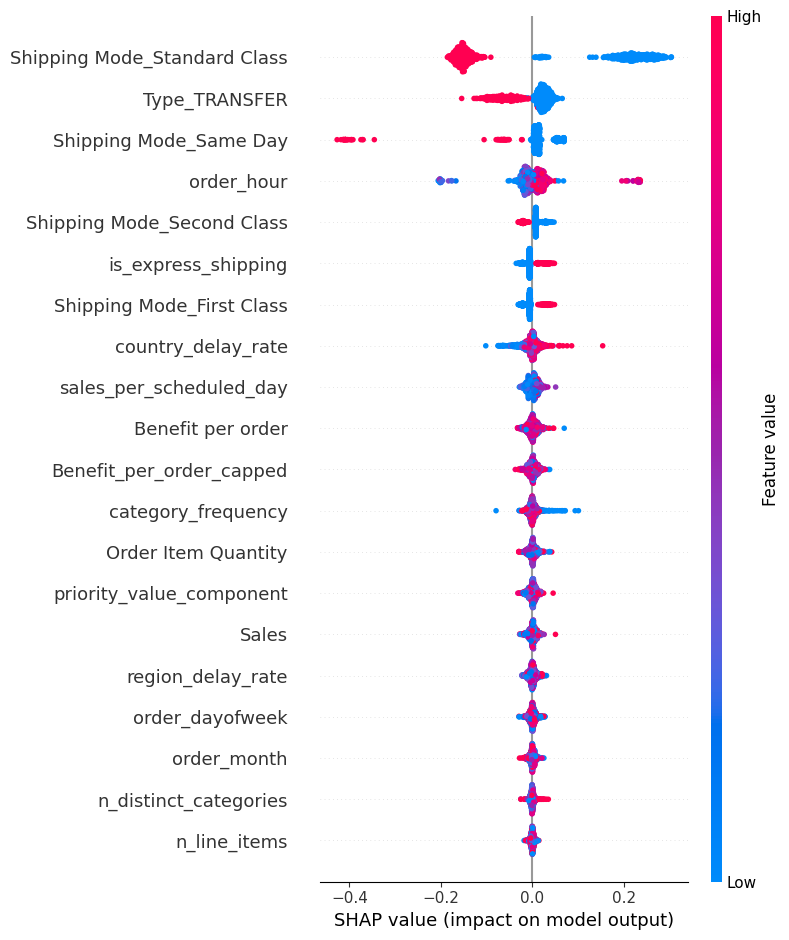

In [3]:
import shap
import time
import matplotlib.pyplot as plt

FIG_DIR = Path('../../../reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

def positive_class_shap(sv):
    """Return a 2D (rows x features) SHAP array for the 'Late' class (class 1).
    Handles every format SHAP versions return:
      - old versions: list of 2 arrays            -> take element [1]
      - new versions: 3D array (rows, features, classes) -> take [:, :, 1]
      - already 2D (e.g. XGBoost binary)          -> use as is
    """
    if isinstance(sv, list):
        return np.asarray(sv[1])
    sv = np.asarray(sv)
    if sv.ndim == 3:
        return sv[:, :, 1]
    return sv

def positive_class_base(ev):
    ev = np.atleast_1d(np.asarray(ev))
    return float(ev[1] if ev.size > 1 else ev[0])

t0 = time.time()
print("Building TreeExplainer for Random Forest...")
explainer_rf = shap.TreeExplainer(tuned_rf)
print(f"  explainer built in {time.time()-t0:.1f}s")

t0 = time.time()
print(f"Computing SHAP values for {len(X_val_shap)} sampled rows (this is the slow step)...")
shap_values_rf = explainer_rf.shap_values(X_val_shap, check_additivity=False)
print(f"  SHAP values computed in {time.time()-t0:.1f}s")

sv_rf = positive_class_shap(shap_values_rf)
base_rf = positive_class_base(explainer_rf.expected_value)
print("raw SHAP output shape:", np.shape(shap_values_rf), "-> using", sv_rf.shape)

shap.summary_plot(sv_rf, X_val_shap, show=False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_summary_rf.png', dpi=120, bbox_inches='tight')
plt.show()

**What we found (Random Forest):** *(fill in — where does order_hour rank in this SHAP summary compared to Shipping Mode features? This is the real answer to the discrepancy between the two earlier importance charts.)*


## 2. SHAP values for the tuned XGBoost

XGBoost SHAP values computed in 0.9s, shape (1000, 28)


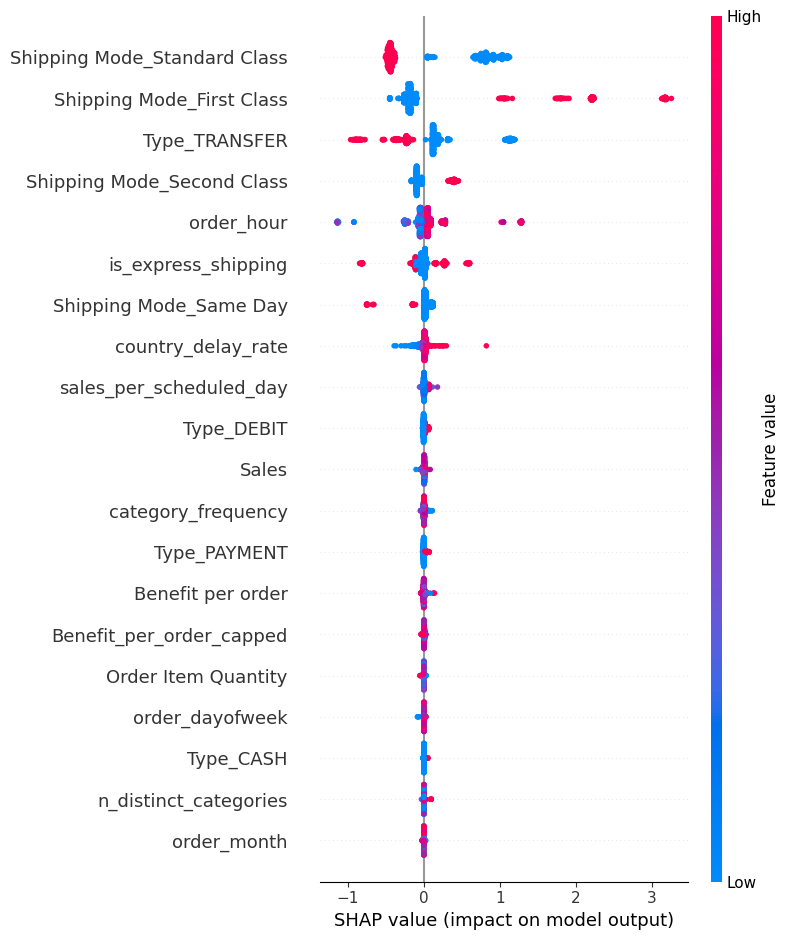

In [4]:
t0 = time.time()
explainer_xgb = shap.TreeExplainer(tuned_xgb)
shap_values_xgb = explainer_xgb.shap_values(X_val_shap, check_additivity=False)
sv_xgb = positive_class_shap(shap_values_xgb)
print(f"XGBoost SHAP values computed in {time.time()-t0:.1f}s, shape {sv_xgb.shape}")

shap.summary_plot(sv_xgb, X_val_shap, show=False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_summary_xgb.png', dpi=120, bbox_inches='tight')
plt.show()

**What we found (XGBoost):** *(fill in — same check for XGBoost. If both models' SHAP rankings agree with each other, that's a strong, trustworthy answer to the order_hour question, one way or the other. If they disagree even under SHAP, that's a genuinely interesting finding about how differently the two algorithms are using the same feature.)*


## 3. Dependence plot — checking the interaction-effect hypothesis for order_hour

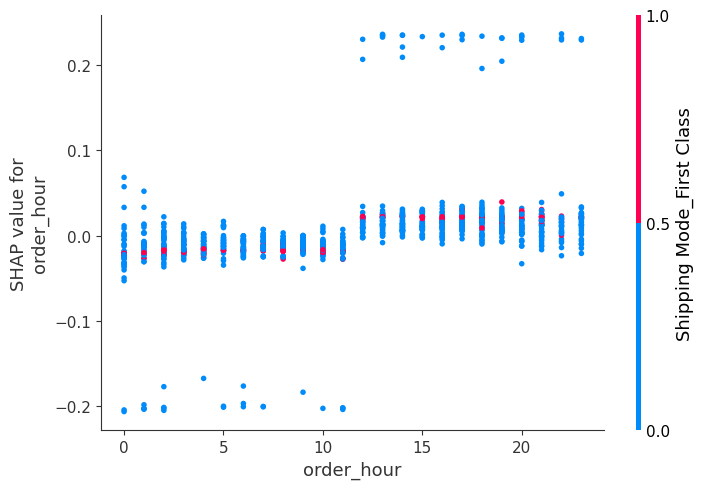

In [5]:
shap.dependence_plot('order_hour', sv_rf, X_val_shap,
                     interaction_index='Shipping Mode_First Class', show=False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_dependence_order_hour.png', dpi=120, bbox_inches='tight')
plt.show()

**What we found:** *(fill in — this directly tests the hypothesis from the model development stage: does order_hour's effect on the prediction change depending on Shipping Mode? If the plot shows a clear color-based split (points colored by Shipping Mode landing at different heights for the same hour), that confirms a real interaction effect. If the pattern looks like random noise with no clear structure, that suggests the earlier permutation-importance signal may have been picking up something less meaningful than a genuine interaction.)*


## 4. Individual order explanation (prototype for the app's explainability panel)

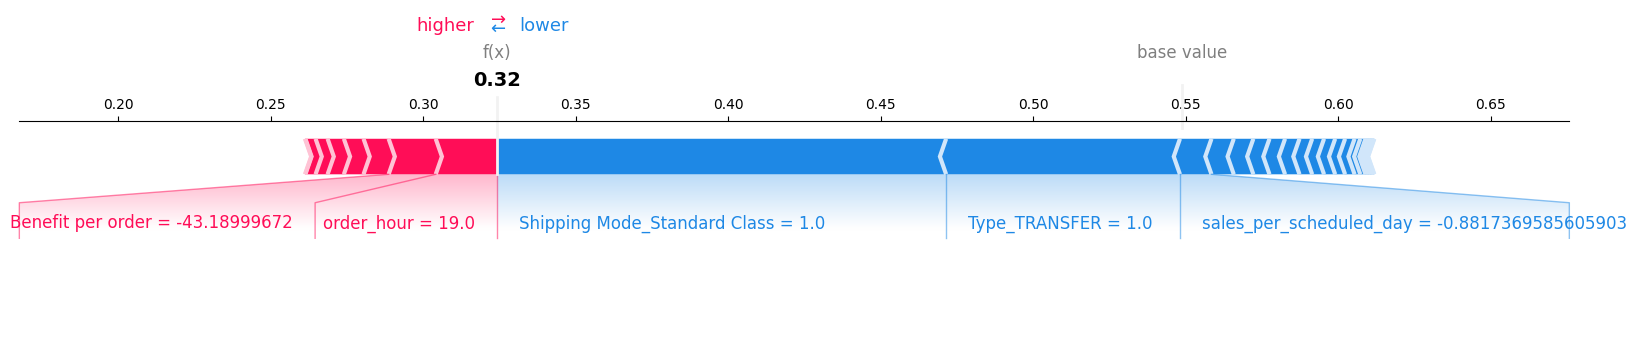

In [6]:
sample_idx = 0  # position within X_val_shap, not the original X_val

# sv_rf[sample_idx] is now a 1D vector (one order, 28 features), which is what
# matplotlib=True force plots require.
shap.force_plot(base_rf,
                sv_rf[sample_idx],
                X_val_shap.iloc[sample_idx],
                matplotlib=True, show=False)
plt.savefig(FIG_DIR / 'shap_force_plot_example.png', dpi=120, bbox_inches='tight')
plt.show()

**What we found:** *(fill in — this individual explanation is a direct prototype for the "why is this risky?" panel planned for the Streamlit app. Note which features pushed this specific order's risk up or down, and confirm the explanation reads as genuinely understandable to a non-technical operations user, not just to us.)*
